Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


TEXT GENERATION
Artificial Intelligence is an open source framework for building open data applications. The framework has been designed for use with popular open source projects such as Google-Qt, Red Hat, and others. We hope that this framework


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

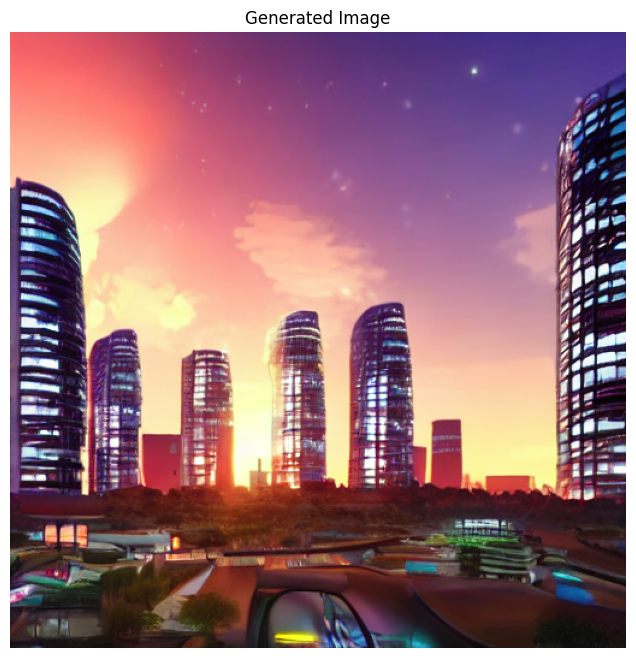

Audio saved successfully!

Audio saved as generated_audio.mp3


In [3]:
# ==========================================================
# Experiment 11
# Multimedia Content Generation using Foundation Models
# ==========================================================

# Install Required Libraries
!pip install -q transformers diffusers accelerate sentencepiece \
huggingface_hub safetensors gtts

# ----------------------------------------------------------
# Hugging Face Login (Optional)
# ----------------------------------------------------------

from google.colab import userdata
from huggingface_hub import login

try:
    token = userdata.get("HuggingFace")
    login(token=token)
except:
    print("Proceeding without Hugging Face login...")

# ----------------------------------------------------------
# Import Libraries
# ----------------------------------------------------------

import torch
import matplotlib.pyplot as plt

from transformers import pipeline
from diffusers import StableDiffusionPipeline

from gtts import gTTS
from IPython.display import Audio

# ==========================================================
# PART 1 : Text Generation
# ==========================================================

text_generator = pipeline(
    "text-generation",
    model="gpt2"
)

prompt = "Artificial Intelligence is"

text = text_generator(
    prompt,
    max_new_tokens=40,
    do_sample=True,
    temperature=0.8
)

print("="*60)
print("TEXT GENERATION")
print("="*60)

generated_text = text[0]["generated_text"]

print(generated_text)

# ==========================================================
# PART 2 : Image Generation
# ==========================================================

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

image_prompt = "A futuristic smart city at sunset"

image = pipe(image_prompt).images[0]

plt.figure(figsize=(8,8))
plt.imshow(image)
plt.axis("off")
plt.title("Generated Image")
plt.show()

image.save("generated_image.png")

# ==========================================================
# PART 3 : Speech Generation
# ==========================================================

# Clean the generated text
clean_text = generated_text.replace("\n", " ")
clean_text = clean_text.replace('"', "")
clean_text = clean_text[:300]   # Keep only first 300 characters

tts = gTTS(
    text=clean_text,
    lang="en",
    slow=False
)

tts.save("generated_audio.mp3")

print("Audio saved successfully!")

tts.save("generated_audio.mp3")

print("\nAudio saved as generated_audio.mp3")

Audio("generated_audio.mp3")
